[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lmassaron/gemma_from_scratch/blob/main/workshop/01_the_math_of_attention.ipynb)


# Workshop: Building Gemma 3 from Scratch
## Notebook 1: The Math of Attention (QK-Norm)

**Estimated Time: 15 minutes**

In this notebook, we implement the **core mechanism** of Gemma 3's decoder: **Query-Key Attention**. The key architectural shift in Gemma 3 is replacing the soft-capping (tanh at 50.0) of Gemma 2 with **QK-Norm** -- L2-normalizing both Q and K before computing dot products.

## Learning Objectives:
1. Understand the Query (Q), Key (K), and Value (V) analogy.
2. Implement attention with **QK-Norm** (Gemma 3's core innovation).
3. Understand why scaling by $1/\sqrt{d_k}$ is still needed after QK-Norm.
4. Visualize how Softmax creates an attention map.
5. Understand why final logits are capped at 30.0.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import sys

print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")

# Set seed for reproducibility
_ = torch.manual_seed(42)

# Gemma 3 architecture parameters
head_dim = 96  # hidden_size=768 / num_heads=8
seq_len = 8
batch_size = 1
logit_cap = 30.0  # Gemma 3 final logit capping

Python version: 3.12.13 (main, Mar 10 2026, 18:15:41) [Clang 21.1.4 ]
PyTorch version: 2.5.1


## 1. The Q, K, V Analogy

Imagine you are in a library:
- **Query (Q)**: The topic you are searching for (e.g., "How do transformers work?").
- **Key (K)**: The labels on the spines of the books (e.g., "Deep Learning", "Gardening", "Attention Mechanisms").
- **Value (V)**: The actual content inside the books.

Attention matches your **Query** against all **Keys**, computes a similarity score, and uses that score to decide how much of each **Value** you should read.

In Gemma 2, we capped scores with tanh. In **Gemma 3**, we use **QK-Norm**: normalize Q and K vectors to unit length before the dot product, making scores purely cosine similarities.

In [2]:
# Create dummy Q, K, V tensors
# Shape: (batch, seq_len, head_dim)
Q = torch.randn(batch_size, seq_len, head_dim)
K = torch.randn(batch_size, seq_len, head_dim)
V = torch.randn(batch_size, seq_len, head_dim)

print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")
print(f"V shape: {V.shape}")

# Verify they have the same head dimension
assert Q.shape[-1] == K.shape[-1] == V.shape[-1] == head_dim
print("✅ Shapes are consistent!")

Q shape: torch.Size([1, 8, 96])
K shape: torch.Size([1, 8, 96])
V shape: torch.Size([1, 8, 96])
✅ Shapes are consistent!


## 2. QK-Norm: The Gemma 3 Innovation

In **Gemma 2**, each Q and K was scaled by $1/\sqrt{d_k}$ and scores were capped with `tanh(scores / 50.0)`. 

In **Gemma 3**, the architecture was simplified: we **L2-normalize** Q and K, so their dot product is exactly the cosine similarity. This makes scores inherently bounded in [-1, 1] -- removing the need for the 50.0 soft-cap on attention scores.

$$\hat{Q} = \frac{Q}{\|Q\|_2}, \quad \hat{K} = \frac{K}{\|K\|_2}, \quad Score = \hat{Q} \cdot \hat{K}^T$$

QK-Norm has two big advantages:
1. **Stability**: dot products are bounded, preventing gradient explosion
2. **Simplicity**: no arbitrary 50.0 cap constant needed in the forward pass

In [3]:
# QK-Norm: L2 normalize Q and K
Q_norm = F.normalize(Q, p=2, dim=-1)
K_norm = F.normalize(K, p=2, dim=-1)

print(f"Q_norm norms: {Q_norm.norm(dim=-1)[0]}")
print(f"K_norm norms: {K_norm.norm(dim=-1)[0]}")

# Verify L2 normalization worked
assert torch.allclose(
    Q_norm.norm(dim=-1), torch.ones_like(Q_norm.norm(dim=-1)), atol=1e-6
)
print("✅ QK-Norm applied: all Q and K vectors have unit norm!")

Q_norm norms: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
K_norm norms: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
✅ QK-Norm applied: all Q and K vectors have unit norm!


## 3. Computing Attention Scores

Now compute dot products between normalized Q and K. Since both are unit vectors, the score is the cosine similarity, bounded in [-1, 1].

*Note:* We still divide by $\sqrt{d_k}$ to prevent very small gradients when head_dim is large -- this is a convention carried over, though less critical with QK-Norm.

In [4]:
# Compute attention scores with QK-Norm
scores = torch.matmul(Q_norm, K_norm.transpose(-2, -1)) / math.sqrt(head_dim)

print(f"Scores shape: {scores.shape}")
print(f"Score range: [{scores.min():.4f}, {scores.max():.4f}]")
print(f"\nSample scores (first query vs all keys):\n{scores[0, 0]}")

# With QK-Norm, scores are naturally bounded (unlike raw dot products)
import math

print(f"\nScore std without normalization: ~{scores.std().item():.4f}")
print("With QK-Norm, scores are much more stable!")

Scores shape: torch.Size([1, 8, 8])
Score range: [-0.0257, 0.0234]

Sample scores (first query vs all keys):
tensor([ 0.0037, -0.0122, -0.0085, -0.0047,  0.0155, -0.0150, -0.0070, -0.0102])

Score std without normalization: ~0.0111
With QK-Norm, scores are much more stable!


## 4. Softmax and Attention Weights

Attention Weights (Sum of row 1): 1.0

These weights sum to 1.0 -- they are a probability distribution.


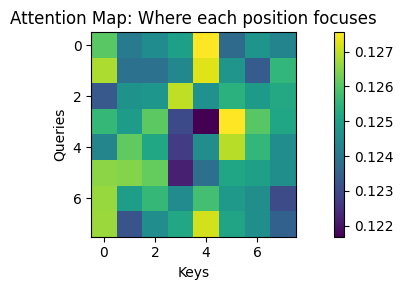

In [5]:
# Apply softmax to get attention weights
attention_weights = F.softmax(scores, dim=-1)

print("Attention Weights (Sum of row 1):", attention_weights[0, 0].sum().item())
print("\nThese weights sum to 1.0 -- they are a probability distribution.")

# Visualized as a heatmap
plt.figure(figsize=(8, 3))
plt.imshow(attention_weights[0].detach().numpy(), cmap="viridis")
plt.colorbar()
plt.title("Attention Map: Where each position focuses")
plt.xlabel("Keys")
plt.ylabel("Queries")
plt.tight_layout()
plt.show()

## 5. The Final Output

In [6]:
# Weighted sum of Value vectors
output = torch.matmul(attention_weights, V)
print(f"Output shape: {output.shape}")

# The output is a context-aware representation of each position
print(f"\nFirst token's context vector (first 5 dims):\n{output[0, 0, :5]}")

Output shape: torch.Size([1, 8, 96])

First token's context vector (first 5 dims):
tensor([-0.5444, -0.2651,  0.4295, -0.0465, -0.1678])


## 6. Final Logit Soft-Capping

After the transformer produces its output, Gemma 3 caps the **final logits** at 30.0 via tanh. This is separate from attention score normalization:

## Why cap logits at 30.0?
- Prevents the softmax at the output layer from becoming **too peaky**
- A peaky softmax means extreme confidence: the model picks one word with probability ~1.0
- This causes **vanishing gradients** for all other words, making learning unstable
- The value 30.0 was found empirically to be the "sweet spot" for training stability

Raw logits:     min=-123.5, max=121.6
Capped logits:  min=-30.0, max=30.0


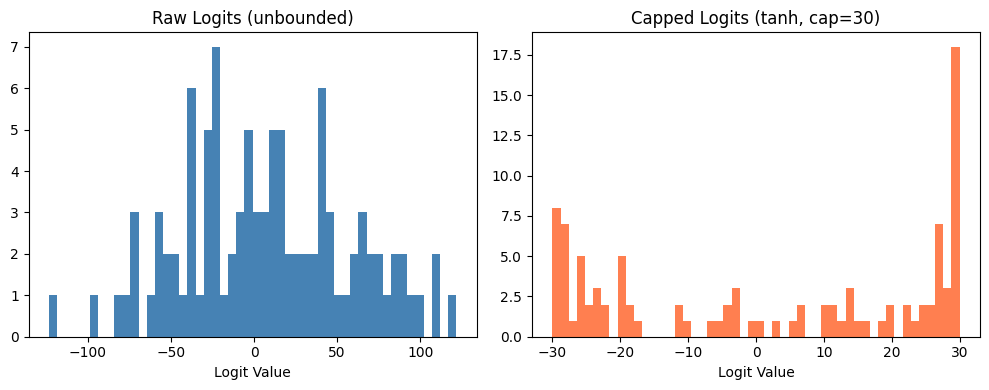

In [7]:
def final_logit_cap(logits, cap=logit_cap):
    """Gemma 3 final logit soft-capping."""
    return cap * torch.tanh(logits / cap)


# Demonstrate the effect
raw_logits = torch.randn(1, 100) * 50  # Unbounded logits
capped_logits = final_logit_cap(raw_logits)

print(f"Raw logits:     min={raw_logits.min():.1f}, max={raw_logits.max():.1f}")
print(f"Capped logits:  min={capped_logits.min():.1f}, max={capped_logits.max():.1f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(raw_logits[0].detach().numpy(), bins=50, color="steelblue")
plt.title("Raw Logits (unbounded)")
plt.xlabel("Logit Value")

plt.subplot(1, 2, 2)
plt.hist(capped_logits[0].detach().numpy(), bins=50, color="coral")
plt.title("Capped Logits (tanh, cap=30)")
plt.xlabel("Logit Value")
plt.tight_layout()
plt.show()

## Exercise:
Write a single function `qk_attention(Q, K, V)` that performs QK-Norm + scaled dot-product attention. Then test it matches the step-by-step computation above.

In [8]:
def qk_attention(Q, K, V):
    """Attention with QK-Norm (Gemma 3 style)."""
    d_k = Q.shape[-1]

    # 1. QK-Norm: L2 normalize both Q and K
    Q_norm = F.normalize(Q, p=2, dim=-1)
    K_norm = F.normalize(K, p=2, dim=-1)

    # 2. Compute dot product scores, scaled by 1/sqrt(dk)
    scores = torch.matmul(Q_norm, K_norm.transpose(-2, -1)) / math.sqrt(d_k)

    # 3. Softmax over the last dimension
    attention_weights = F.softmax(scores, dim=-1)

    # 4. Weighted sum of values
    output = torch.matmul(attention_weights, V)

    return output


# Test your function
test_output = qk_attention(Q, K, V)
assert torch.allclose(test_output, output, atol=1e-6)
print("✅ Success! Your QK-Norm attention matches the expected output.")

✅ Success! Your QK-Norm attention matches the expected output.


<details>
<summary><b>Click to see solution</b></summary>

```python
def qk_attention(Q, K, V):
    d_k = Q.shape[-1]
    Q_norm = F.normalize(Q, p=2, dim=-1)
    K_norm = F.normalize(K, p=2, dim=-1)
    scores = torch.matmul(Q_norm, K_norm.transpose(-2, -1)) / math.sqrt(d_k)
    attention_weights = F.softmax(scores, dim=-1)
    return torch.matmul(attention_weights, V)
```
</details>

## Key Takeaway

Gemma 3 replaced Gemma 2's soft-capping with QK-Norm -- a cleaner way to stabilize attention. The 30.0 final logit capping remains, preventing extreme confidence at the output layer.